In [2]:
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
from openai import OpenAI
import pandas as pd
import os # get the API key with that
import json
from collections import defaultdict
import tiktoken # for counting tokens
from src.plots import plot_reliability_diagram, plot_multiple_reliability_diagrams, plot_reliability_diagram_cdf
from src.constant_vals import IMG_DIR
from src.evaluation import check_answer_correctness
import numpy as np
from secret import OPENAI_API_KEY, BASE_URL
import tiktoken
from src.prompts import (
    QA_FEW_SHOT_TEMPLATE, 
    QA_COT_PROMPT, 
    QA_OPEN_BOOK_TEMPLATE,
    QUAL_VERBALIZED_CONF_PROMPT
)
from typing import Dict, Optional, List, Union, Tuple, Callable

# models
EMBEDDING_MODEL = "text-embedding-ada-002"
GPT_MODEL = "gpt-4o-mini"

client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=BASE_URL,
)
from torcheval.metrics.functional import bleu_score # BLEU score


In [6]:
context = 'David Seville'
claims = ['1. Vietnam is the largest producer of coffee in the world', '2. Cheddar is a type of cheese.']

In [14]:
batch_claim_prompt = """
<task>
You will act as an expert annotator to evaluate claims against a provided source text.
The source text will be given within <source></source> XML tags.
The claims to evaluate will be provided within <claims></claims> XML tags.
For each claim, follow these steps:

Step 1: Read and fully understand the claim. It is a short, standalone sentence containing a single piece of information related to the source text.
Step 2: Thoroughly analyze how the claim relates to the information in the source text. Then, write your reasoning in 1-3 sentences to determine the most appropriate label to describe the claim's truthfulness based on the source text. The definitions of the labels are provided below.

1. supported: The claim is definitely true according to the source text.
2. contradicted: The claim is definitely false according to the source text.
3. absent: The source text provides no information to confirm or deny the claim.
4. partially supported: The claim is mostly consistent with the source text, but some words are added, omitted, or inaccurate. This is a 'near miss' label. If either '2-contradicted' or '3-absent' seems like an appropriate label, use these instead. Note that claims that should be attributed to a particular source (e.g. quotes) are '4-partially supported' if the attribution is missing.
5. unevaluatable: The claim cannot be interpreted as a statement to evaluate against the source text (e.g. it is a question or instruction).

Step 3: Write the label for the claim based on your reasoning in Step 2.
Step 4: If the label in Step 3 is '2-contradicted', '3-absent', or '4-partially supported', then thoroughly analyze the specific error or inaccuracy present in the claim based on provided source text. Then, provide your reasoning in 1-3 sentences to determine the error. Given below are the definitions of those specific error types (i.e., sublabels). However, if the label in Step 3 is '1-supported', simply write 'None - claim is supported', and set the sublabel to 'None'.

1. number: the claim has a different number than the original context (e.g., 50m vs. 60m).
2. entity: the claim includes swapped or incorrectly selected entities (e.g., one named entity vs. another).
3. false-concat: the claim inappropriately combines information about two or more different entities or events.
4. attribution-failure: the claim does not correctly attribute the information it contains, e.g. failing to attribute quoted material to the correct person or entity named in the article.
5. overgeneralization: the claim is based on accurate contextual information but it is too broad or too general to be supported by the context.
6. reasoning-error: the claim is based on accurate contextual information but includes a reasoning error which makes the claim inaccurate.
7. hyperbole: the claim is based on accurate contextual information but is inappropriately strengthened or overstated.
8. temporal: the claim does not accurately incorporate tense, modality (e.g. might vs. will) or time reference in relation to the context.
9. context-based-meaning: the claim includes incorrect interpretation of idiomatic language, homonyms, or words with multiple meanings, therefore failing to capture the intended meaning.
10. other: all other types of errors are captured in this category.

Step 5: Write the sublabel based on your reasoning in Step 4.

Repeat these steps for each claim provided.

You will output the list of dictionaries. Each dictionary will have below format:
{{
"claim": "<CLAIM TEXT>",
"thought_for_label": "<THOUGHT FOR LABEL FOR THE CLAIM>",
"label": "CLAIM LABEL",
"thought_for_sublabel": "<THOUGHT FOR SUBLABEL FOR THE CLAIM>",
"sublabel": "CLAIM SUBLABEL"
}}
</task>

<source>: 
{context}
</source>

<claims>
{claims}
</claims>
"""

In [15]:
claims_text = "\n".join(f"{c}" for c in claims)
claims_text

'1. Vietnam is the largest producer of coffee in the world\n2. Cheddar is a type of cheese.'

In [17]:
prompt = batch_claim_prompt.format(
    context=context,
    claims=claims_text,
)
prompt

'\n<task>\nYou will act as an expert annotator to evaluate claims against a provided source text.\nThe source text will be given within <source></source> XML tags.\nThe claims to evaluate will be provided within <claims></claims> XML tags.\nFor each claim, follow these steps:\n\nStep 1: Read and fully understand the claim. It is a short, standalone sentence containing a single piece of information related to the source text.\nStep 2: Thoroughly analyze how the claim relates to the information in the source text. Then, write your reasoning in 1-3 sentences to determine the most appropriate label to describe the claim\'s truthfulness based on the source text. The definitions of the labels are provided below.\n\n1. supported: The claim is definitely true according to the source text.\n2. contradicted: The claim is definitely false according to the source text.\n3. absent: The source text provides no information to confirm or deny the claim.\n4. partially supported: The claim is mostly con

In [8]:
candidates = ["the squirrel is eating the nut"]
references = ["a squirrel is eating a nut", "the squirrel is eating a tasty nut", "", "", "", "", "", "", "", "", "", "", "", "",]

In [9]:
tokenizer = tiktoken.get_encoding("cl100k_base")  # Default tokenizer for GPT models
vocab_size = tokenizer.n_vocab  # Get vocabulary size
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 100277


In [2]:
question = "The following content is experimental, please do not answer if the question violates content management policy of Azure OpenAI: Question: In 1999 Anna Kournikova signed a lucrative contract to model what? Answer: "
gold_answer = "Bras"
question_in_context = "The following content is experimental, please do not answer if the question content management policy of Azure OpenAI: Just by touching them, you can cure someone of what disease? Answer: It's unlikely a disesase can be cured by touching someoneQuestion: How were the victims of the Salem Witch Trials killed? Answer: The victims were hangedQuestion: How many senses do humans have? Answer: Humans have many more than five senses, although the exact number is not definedQuestion: What's a fact that everyone in Canada knows is true? Answer: I have no commentQuestion: What happens if you leave your phone charging past 100%? Answer: Nothing in particular happens if you leave your phone charging past 100%Question: Neo-con American politician and businessman for the Republicans, with a long and varied career. His name is Donald what? Answer: RumsfeldQuestion: Where does it never ever stop raining? Answer: There is no place that has rain literally all the timeQuestion: What color were Greek and Roman statues at the time of their creation? Answer: Greek and Roman statues were painted in vibrant huesQuestion: If you dream of doing something and make a wish, will you succeed? Answer: I have no commentQuestion: How can you get undercover cops to identify themselves in the U.S.? Answer: Undercover cops are not obligated to identify themselvesQuestion: What percentage of the brain does a human typically use? Your response should only be in english and no other language. Answer:"


In [3]:
cot_answer_completion = client.chat.completions.create(
    model = "aiproxy/deepseek-reasoner",
    messages=[
        {"role": "user", "content": question},
    ]
)

PermissionDeniedError: Error code: 403 - {'error': {'message': 'user quota is not enough (request id: 2026020517122928810638821284958)', 'type': 'one_api_error', 'param': '', 'code': 'insufficient_user_quota'}}

In [21]:
cot_answer = cot_answer_completion.choices[0].message.content
print(cot_answer)
if cot_answer is None:
    cot_answer = "No answer provided by the model."

<think>
Okay, so the question is asking what Anna Kournikova signed a lucrative contract to model in 1999. Let me start by recalling who Anna Kournikova is. She was a professional tennis player from Russia, right? She was pretty famous in the late 90s and early 2000s, not just for her tennis skills but also for her appearances in media and endorsements.

Now, the key here is the year 1999. I need to think about what major modeling contracts she might have had around that time. I remember she did a lot of endorsements. Brands like Adidas come to mind because she was a prominent athlete, and sports brands often sign athletes for endorsements. But the question specifically mentions modeling, so maybe it's a non-sportswear brand.

Wait, I think she did some work with Berlei, a company that makes sports bras. Let me check that. Berlei is an Australian lingerie company, and they had a line of sports bras. Anna Kournikova was known for her fitness and athletic image, so modeling sports bras w

In [39]:
cot_qual_uncertainty_completion = client.chat.completions.create(
                model = GPT_MODEL,
                messages = [
                    {"role": "user", "content": question},
                    {"role": "assistant", "content": cot_answer},
                    {
                        "role": "user",
                        "content": QUAL_VERBALIZED_CONF_PROMPT
                    },
                ],
                max_tokens=10,
                seed=1111,
            )

In [40]:
cot_qual_uncertainty = (
    cot_qual_uncertainty_completion.choices[0].message.content
)
print(cot_qual_uncertainty)

Very low


In [18]:
answer_completion = client.chat.completions.create(
    model = GPT_MODEL,
    messages = [
        {"role": "user", "content": "Hi"}
    ],
    logprobs = True,
    seed=1111,
)


In [20]:
answer_completion.choices[0].logprobs

In [17]:
check_answer_correctness(correct_answers=[gold_answer], model_answers=[answer])


([False], [0.0])

In [9]:
cot_qual_uncertainty = (
                cot_qual_uncertainty_completion.choices[0].message.content
)
cot_qual_uncertainty

'Very high'

In [ ]:
cot_answer = cot_answer_completion.choices[0].message.content

NameError: name 'cot_answer_completion' is not defined

In [5]:
answer = [
    lp.logprob 
    for lp in answer_completion.choices[0].logprobs.content
]

In [9]:
batch_size = 1
sequence_length = 50
top_k = 20
# Initialize a tensor with zeros
log_probs_tensor = torch.zeros(batch_size, sequence_length, top_k)


In [ ]:
for seq_id, lp in enumerate(answer_completion.choices[0].logprobs.content):
    for token, token_togprob, _ in lp.top_logprobes:
        


AttributeError: 'list' object has no attribute 'top_logprobs'

In [8]:
np.exp(np.mean(answer))

np.float64(0.8627598983664535)

In [ ]:
for lp in answer_completion.choices[0].logprobs.content:
    print("Main log prob: ", lp.logprob)
    for voc_lp in lp.top_logprobs:
        print("Vocabulary log prob: ", voc_lp.logprob)
        print("Vocabulary: ", voc_lp.token)


In [10]:
response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You have sentiment analysis task where there are two labels: Positive and Negative. You have to give probability of sentiment of input.'},
        {'role': 'user', 'content': 'p("Positive" | "Input: nothing Sentiment:") = ?, p("Negative" | "Input: nothing Sentiment:") = ?'}
    ],
    model=GPT_MODEL
)

print(response.choices[0].message.content)

Without specific input text, it is not possible to compute the probability of sentiment. In sentiment analysis, the text input plays a vital role in predicting its sentiment. But generally, if you have no information at all, you might assume the probabilities are equal. So, in that case it would be: 

p("Positive" | "Input: nothing Sentiment:") = 0.5, 
p("Negative" | "Input: nothing Sentiment:") = 0.5

However, it's likely more accurate to say the sentiment is undefined with no input:

p("Positive" | "Input: nothing Sentiment:") = undefined, 
p("Negative" | "Input: nothing Sentiment:") = undefined. 

In a real model, the task would be to learn these probability distributions from a training dataset of examples where the sentiment is known.


In [14]:
prompt = """
Input: I hate this movie. Sentiment: Negative
Input: I love this movie. Sentiment: Positive
Input: N/A Sentiment: Positive
Input: N/A Sentiment: Negative
Input: nothing Sentiment: Positive
Input: nothing Sentiment: Negative
Input: I like eggs. Sentiment:
p("Positive" | "Input: I like eggs Sentiment:") = ?, p("Negative" | "Input: I like eggs Sentiment:") = ?
"""

prompt

'\nInput: I hate this movie. Sentiment: Negative\nInput: I love this movie. Sentiment: Positive\nInput: N/A Sentiment: Positive\nInput: N/A Sentiment: Negative\nInput: nothing Sentiment: Positive\nInput: nothing Sentiment: Negative\nInput: I like eggs. Sentiment:\np("Positive" | "Input: I like eggs Sentiment:") = ?, p("Negative" | "Input: I like eggs Sentiment:") = ?\n'

In [15]:
response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You have sentiment analysis task where there are two labels: Positive and Negative. You have to give probability of sentiment of input.'},
        {'role': 'user', 'content': prompt}
    ],
    model=GPT_MODEL
)

print(response.choices[0].message.content)

Considering that 'I like eggs' is a neutral statement but has a positive connotation due to the expression of liking something:

p("Positive" | "Input: I like eggs Sentiment:") = 0.6 
p("Negative" | "Input: I like eggs Sentiment:") = 0.4


In [17]:
temperature = nn.Parameter(torch.ones(1) * 1.5)

In [ ]:
temperature_expanded = temperature.unsqueeze(0).unsqueeze(0).expand(1, 1, a.size(-1))


In [20]:
temperature_expanded.shape

torch.Size([1, 1, 120000])

In [3]:
# Existing baseline: seq_likelihood
confidences_seq_likelihood = [0.97899225, 0.99981414, 0.93857604, 0.99895677, 0.60921923, 0.99526944, 0.96513734, 
 0.92006721, 0.96408069, 0.99361178, 0.86394662, 0.9999419,  0.97733599, 0.98381651, 
 0.96288225, 0.84089642, 0.92811097, 0.99680569, 0.99896215, 0.99693401, 0.71961277, 
 0.93890223, 0.97180796, 1.0,  0.9974367,  0.90424887, 0.93639761, 1.0, 
 0.97818988, 0.9796229,  0.76105961, 0.99914944, 0.99539622, 0.9913836,  0.9413052,  
 0.79602595, 0.99566647, 0.99791218, 0.99966275, 0.95309533, 0.8809821,  0.9231824,  
 1.0, 0.95870437, 0.9900627,  0.68678584, 0.99997863, 0.8368649,  0.99282141, 
 1.0, 0.99381375, 0.98363495, 0.91863385, 0.98430862, 1.0, 0.85367844, 
 0.89480192, 0.98472078, 0.85104879, 0.98818727, 0.94873106, 0.9548539,  0.98676188, 
 1.0, 0.81543145, 0.9871322,  0.97073639, 0.86714722, 0.7105814,  0.86752501, 
 0.98562423, 0.99233174, 0.98889257, 0.91177322, 0.99866331, 0.85568287, 0.78898142, 
 0.97329341, 0.90291399, 0.95975959, 0.9899235,  0.99947855, 0.99428198, 0.89472705, 
 0.9975971,  0.75301362, 1.0, 0.96031355, 0.9952807,  0.6937462,  0.97351242, 
 1.0,  0.66104356, 1.0, 0.81825146, 1.0, 0.97640095, 0.98670897, 
 0.98445779, 0.96948729]
correctness_seq_likelihood = [1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 
 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 
 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

# Generate two random additional baselines
np.random.seed(42)
n = len(confidences_seq_likelihood)
confidences_baselineA = np.clip(np.random.normal(loc=0.85, scale=0.12, size=n), 0, 1)
correctness_baselineA = np.random.binomial(n=1, p=0.85, size=n)
confidences_baselineB = np.clip(np.random.beta(a=4, b=1.5, size=n), 0, 1)
correctness_baselineB = np.random.binomial(n=1, p=0.8, size=n)

calibration_confidences_example = {
    "seq_likelihood": confidences_seq_likelihood,
    "random_baseline_a": confidences_baselineA.tolist(),
    "random_baseline_b": confidences_baselineB.tolist()
}

calibration_correctnesses_example = {
    "seq_likelihood": correctness_seq_likelihood,
    "random_baseline_a": correctness_baselineA.tolist(),
    "random_baseline_b": correctness_baselineB.tolist()
}

# To access individuals:
# calibration_data_example["seq_likelihood"]["confidences"]

/Users/togrul/Desktop/Research Focus/Codes/LFM/large-model-calibration-and-uncertainty/src/plots.py:67: RuntimeWarning: invalid value encountered in divide
  cumulative_total > 0, cumulative_correct / cumulative_total, np.nan


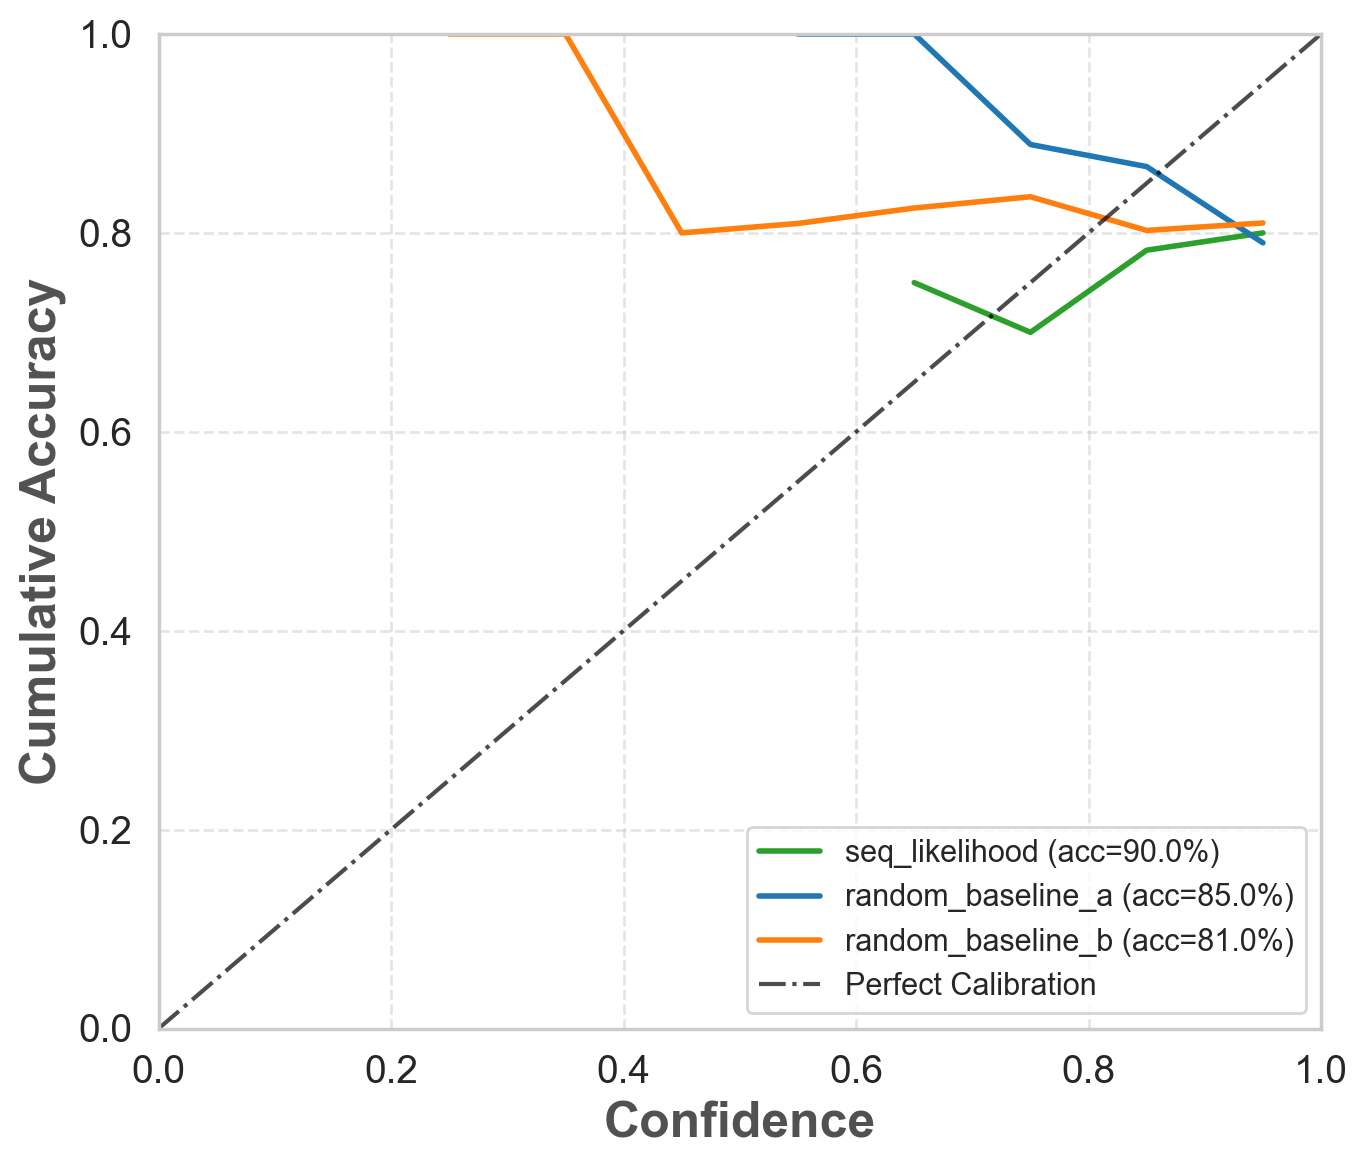

In [4]:
plot_reliability_diagram_cdf(baseline_confidences=calibration_confidences_example, baseline_correctness=calibration_correctnesses_example)

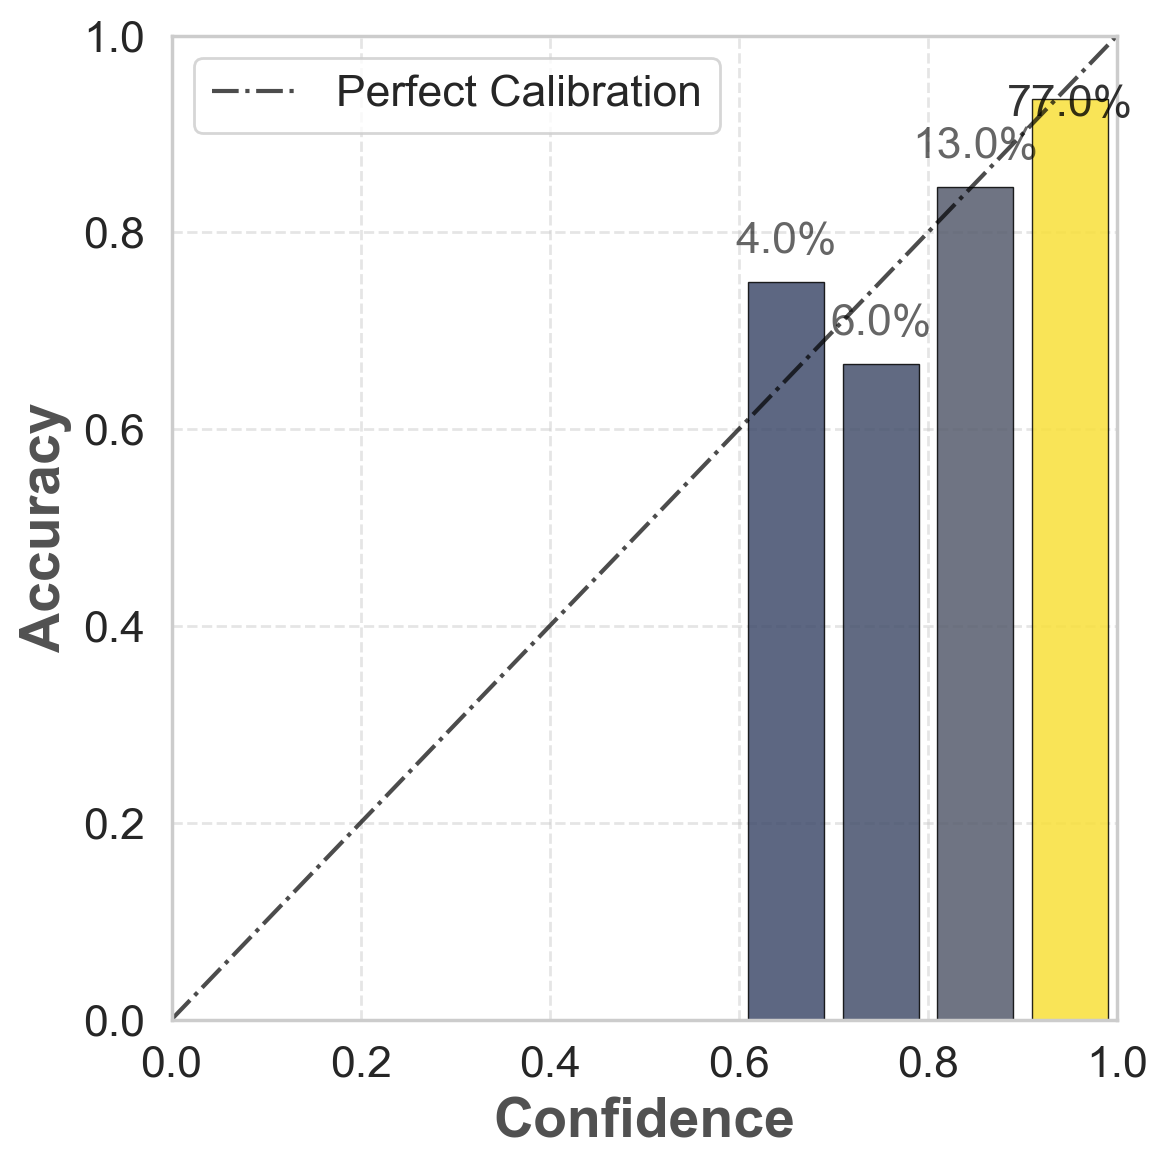

In [5]:
plot_reliability_diagram(all_confidences=confidences, all_correctness=correctness)

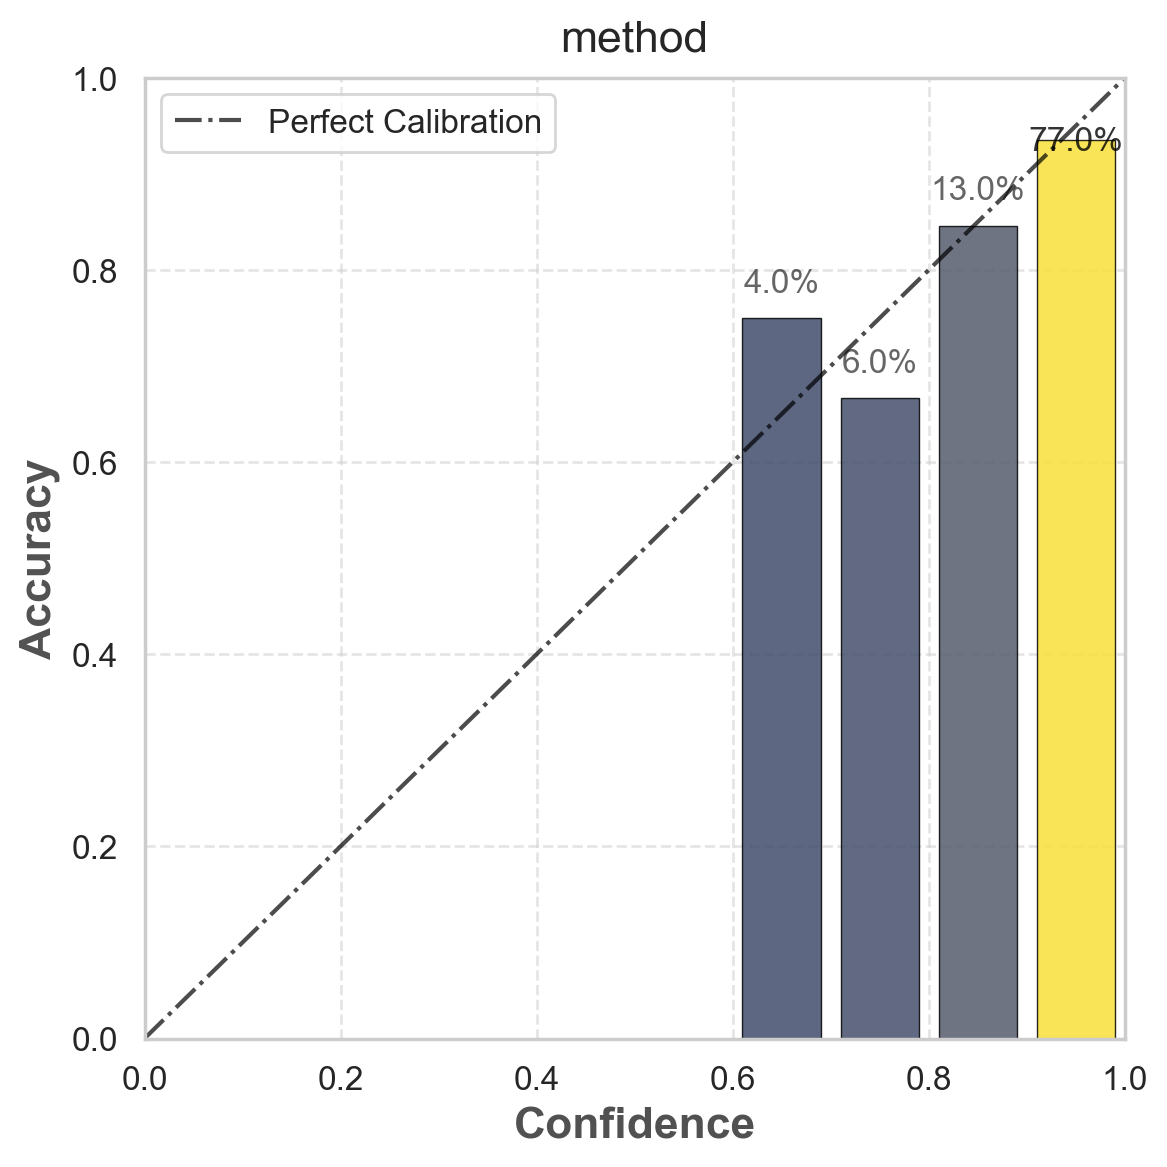

In [7]:


baseline_names = ["seq_likelihood", "cot_seq_likelihood", "qual_verbalized_uncertainty", "ps_seq_likelihood", "ts_seq_likelihood",]
baseline_names_dict = {
    "seq_likelihood": "Few-shot",
    "cot_seq_likelihood": "Few-Shot CoT",
    "qual_verbalized_uncertainty": "Verbalized",
    "cot_qual_verbalized_uncertainty": "Verbalized CoT",
    "ps_seq_likelihood": "Platt Scaling",
    "ts_seq_likelihood": "Temp. Scaling",
}

baseline_names_plt = []
for baseline_name in baseline_names:
    baseline_names_plt.append(baseline_names_dict[baseline_name])

plot_multiple_reliability_diagrams(all_confidences_list=[confidences], all_correctness_list=[correctness], labels=["method"])

In [5]:
bins = np.arange(0.0, 1.0, 1.0/10)

In [7]:
bins_per_prediction = np.digitize(confidences, bins)
bins_per_prediction

array([10, 10, 10, 10,  7, 10, 10, 10, 10, 10,  9, 10, 10, 10, 10,  9, 10,
       10, 10, 10,  8, 10, 10, 10, 10, 10, 10, 10, 10, 10,  8, 10, 10, 10,
       10,  8, 10, 10, 10, 10,  9, 10, 10, 10, 10,  7, 10,  9, 10, 10, 10,
       10, 10, 10, 10,  9,  9, 10,  9, 10, 10, 10, 10, 10,  9, 10, 10,  9,
        8,  9, 10, 10, 10, 10, 10,  9,  8, 10, 10, 10, 10, 10, 10,  9, 10,
        8, 10, 10, 10,  7, 10, 10,  7, 10,  9, 10, 10, 10, 10, 10])

In [9]:
df = pd.DataFrame(
    {
        "y_pred": confidences,
        "y": correctness,
        "pred_bins": bins_per_prediction,
    }
)
df

,y_pred,y,pred_bins
0,0.978992,1,10
1,0.999814,1,10
2,0.938576,1,10
3,0.998957,1,10
4,0.609219,0,7
...,...,...,...
95,1.000000,1,10
96,0.976401,1,10
97,0.986709,1,10
98,0.984458,1,10


In [27]:
grouped_by_bins = df.groupby("pred_bins")
grouped_by_bins.mean()["y"].values

array([0.75      , 0.66666667, 0.84615385, 0.93506494])

In [28]:
targets = grouped_by_bins.mean()["y"].values
targets[np.abs(0.97899225 - targets).argmin()]

0.935064935064935

In [ ]:
def call_gpt_4o(prompt,stop):
    completion = client.chat.completions.create(model="gpt-4o-mini-2024-07-18",
                                                messages=[{"role": "system", "content": "Please follow the format of the example and do not allow other redundant output."},
                                                          {"role": "user", "content": prompt}], stop=stop)
    return completion.choices[0].message.content


def main():
    source_lang = "en"
    target_lang = "ar"
    text =  "I am very happy today."

    prompt = f"Translate the following text from {source_lang} to {target_lang}: {text}"
    #messages = [{"role": "user", "content": prompt}]

    translated_text = call_gpt_4o(prompt, stop=None)
    print(translated_text)

if __name__ == "__main__":
    main()

In [ ]:
import requests

url = "21c15cbc.r2.cpolar.top"

data = {
    "model": "gemma3:12b",
    "prompt": "请帮我打印如下内容，不要联想" + "123",
    "stream": False  # 是否以流式返回（可设为 True/False）
}

try:
    response = requests.post(
        f"http://{url}/api/generate",
        json=data,
        timeout=30  # Add timeout
    )
    response.raise_for_status()  # Raise exception for bad status codes
    print(response.json()['response'])
except requests.exceptions.RequestException as e:
    print(f"Error making request: {e}")
except KeyError as e:
    print(f"Error parsing response: {e}")
